# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 16     |  |
| :-------------|:-------------|
| Felicie van der Leij | 6210392 |
| Ocean Hamerlinck | 6583202 |
| Thijn Holswilder | 6536387 |
| Planning Groep: 16     |Tijdstip / Tijdspanne  |
| eigen condensator af | 12:00 |
| eigen condensator getest | 12:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 15:00-15:15 |
| eigen sensor af | 16:30 |
| eigen sensor getest | 17:00 |
| groep aanwezig 1| Ja |
| groep aanwezig 2| Ja |



## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="opstelling-tekening.jpeg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

from scipy.optimize import curve_fit 
import numpy as np
import matplotlib.pyplot as plt
    
def capaciteit_plaatcondensator(A, d, epsilon_r):
    epsilon_0 = 8.854187817e-12  # F/m

    C = epsilon_0 * epsilon_r * A / d
    return C


# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.
A = 0.1*0.1 # [m^2]
d = 0.001   # [m]
epsilon_r  = 2.5

C = capaciteit_plaatcondensator(A, d, epsilon_r)


print(f"Berekende capaciteit plaatcondensator groep 16 is {C * 1e12:.1f} pF")



Berekende capaciteit plaatcondensator groep 16 is 221.4 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
<img src="daadwerkelijke-opstelling.jpeg" alt="schets student 1" width="400"/>
<img src="amplitude-meting.jpeg" alt="schets student 1" width="400"/>

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 16 | 221.4 pF | 1.113 V | 0.404 V | 80.37 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](de-3-schetsen.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die de massa meet door het verschil in oppervlakte A te meten. We gaan een van de condensator platen vast zetten en de ander hangt aan een veer met known veer constante k. Door een massa aan het veer-plaat systeem te hangen, verschuift de condensator plaat waardoor het oppervlakte van de condensator verranderd. Daarmee kunnen we de verplaatsing delta_x van de veer uitrekenen en omdat we nu veer kracht gelijk stellen aan de zwaartekracht, en omdat we k, g en delat_x weten kunnen de massa m ervan afleiden.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

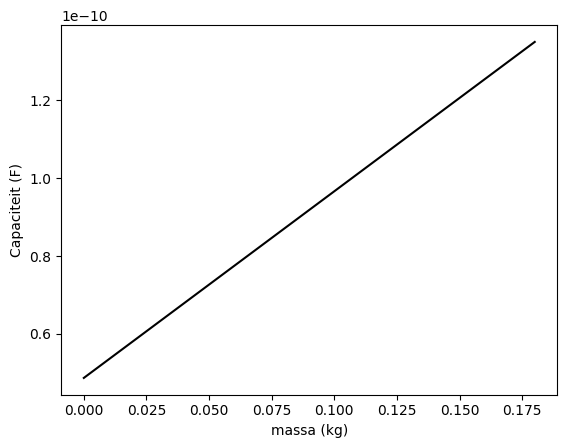

In [3]:
d = 0.001
w=0.1
epsilon_r=2.5
m = np.array([0,180])*1e-3 #de veer kaan een maximaal verschil in massa van 180g meten

x = np.array([2.2,6.1])*1e-2 #onze platen kunnen tussen 2.2cm en 6.1 cm  op elkaar komen
A= x*w
C = capaciteit_plaatcondensator(A,d,epsilon_r)

plt.figure()
plt.plot(m,C, "k-")
plt.xlabel("massa (kg)")
plt.ylabel("Capaciteit (F)")
plt.show()

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (V)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 0 |0 |
| gemiddelde capaciteit| 40,315 |0,20 |
| maximale capaciteit| 80.63 |0,42 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](opstelling1.jpeg)
![meting 2](opstelling_een_meting.jpeg)

## Opdracht 7: Plot de kalibratiegrafiek.

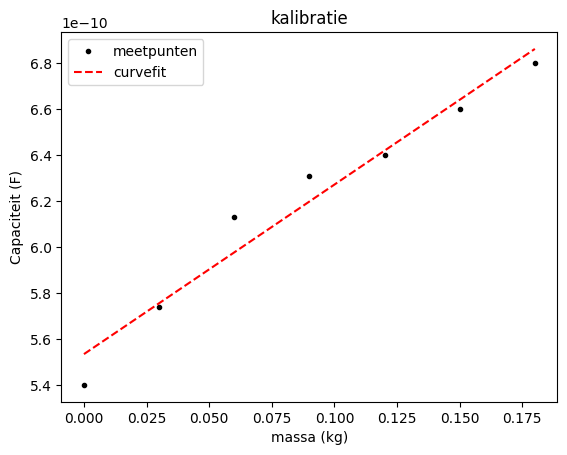

In [15]:

g=9.81 #zwaartekracht constante
d=0.001 #[m] afstand tussen platen
w=0.1 #[m] breedte van platen
epsilon_r=2.5 #carton
epsilon_0 = 8.854187817e-12

#k=0.250*g/0.0517

C_gemeten =  np.array([540,574,613,631,640,660,680])*1e-12
#A = C_gemeten*d/(epsilon_r*epsilon_0) #Oppervlakte
# x = A/w
#x = np.array([0, 3.9/180*30, 3.9/180*60,3.9/180*90,3.9/180*120, 3.9/180*150, 3.9/180*180 ]) + 2.2
#m_uitgerekend = k*x / g
m2= np.array([0,30,60,90,120,150,180])*1e-3

# uit het omschrijven van formules blijkt dat C recht evenreding is met m dus dat er een lineaire fit gemaakt kan worden 
def f(x, a, b):
    return a*x + b

popt,pcov = curve_fit(f, m2, C_gemeten)


x_fit = np.linspace(min(m2), max(m2), 1000)
y_fit = f(x_fit, *popt)
plt.figure()
plt.title('kalibratie')
plt.plot(m2, C_gemeten, "k.", label='meetpunten')
plt.plot(x_fit, y_fit, "r--", label='curvefit')
plt.xlabel("massa (kg)")
plt.ylabel("Capaciteit (F)")
plt.legend()
plt.show()


## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

1. Een houdertje die de afstand tussen de twee platen gelijk houdt

2. Twee platen in het beginpunt verder van elkaar af (zodat de capaciteit nul is aan het begin)

3. Meten met een losse veer om grotere afstanden toe te laten en dus een grotere variatie datapunten te krijgen.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](opstelling2_arduino.jpeg)

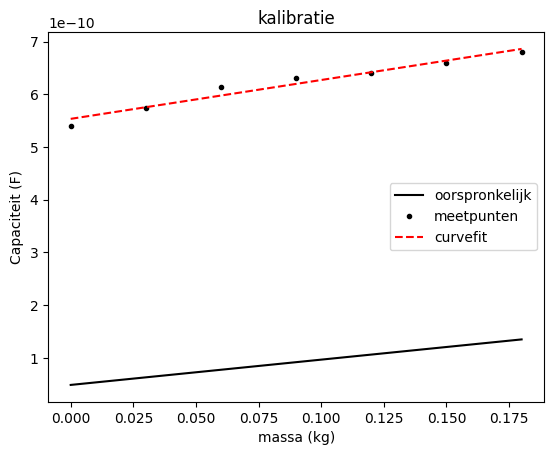

In [16]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
d = 0.001
w=0.1
epsilon_r=2.5
m = np.array([0,180])*1e-3 #de veer kaan een maximaal verschil in massa van 180g meten

x = np.array([2.2,6.1])*1e-2 #onze platen kunnen tussen 2.2cm en 6.1 cm  op elkaar komen
A= x*w
C = capaciteit_plaatcondensator(A,d,epsilon_r)

g=9.81 #zwaartekracht constante
d=0.001 #[m] afstand tussen platen
w=0.1 #[m] breedte van platen
epsilon_r=2.5 #carton
epsilon_0 = 8.854187817e-12

#k=0.250*g/0.0517

C_gemeten =  np.array([540,574,613,631,640,660,680])*1e-12
#A = C_gemeten*d/(epsilon_r*epsilon_0) #Oppervlakte
# x = A/w
#x = np.array([0, 3.9/180*30, 3.9/180*60,3.9/180*90,3.9/180*120, 3.9/180*150, 3.9/180*180 ]) + 2.2
#m_uitgerekend = k*x / g
m2= np.array([0,30,60,90,120,150,180])*1e-3

# uit het omschrijven van formules blijkt dat C recht evenreding is met m dus dat er een lineaire fit gemaakt kan worden 
def f(x, a, b):
    return a*x + b

popt,pcov = curve_fit(f, m2, C_gemeten)


x_fit = np.linspace(min(m2), max(m2), 1000)
y_fit = f(x_fit, *popt)
plt.figure()
plt.title('kalibratie')
plt.plot(m,C, "k-", label='oorspronkelijk')
plt.plot(m2, C_gemeten, "k.", label='meetpunten')
plt.plot(x_fit, y_fit, "r--", label='curvefit')
plt.xlabel("massa (kg)")
plt.ylabel("Capaciteit (F)")
plt.legend()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

We merken dat het lineaire verbant bij de kalibratie en verwachting hetzelfde is. Echter is er een sprong in capacoteit (van ongeveer 5e-10 F) in de gemeten capaciteit door de meerdere onzekerheden beschreven in de iteratie.

Onze sensor zou na veranderingen aangetoond in de iteratie geschikt zijn om het fenomeen dat we wilde meten daadwerkelijk te meten, door het elimineren van grote meetonzekerheden die onze resultaat beïnvloeden (zoals bv de afstand tussen de platen die grote veranderingen in de capaciteit kunnen veroorzaken).

We verwachten dat het een verbetering had opgeleverd (als we de tijd ervoor hadden gehad), echter is onze basis opstelling al best nauwkeurig aangezien we een lineair verbant kunnen aantonen, zoals verwacht.

Er is een verschil die uitgelegd kan worden door variaties in de afstand tussen de platen bij het verplaatsen van de plaat (voor elk gewicht) en het niet gebruik maken van een ideale veer, waarbij de grafiek laat zien dat de meetresultaten en de verwachte lijn dezelfde lineaire vorm hebben maar een constante verschuiving in de y-richting vertonen door een onjuist ingesteld nulpunt.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 16 | 221.4 pF | 1.113 V | 0.404 V | 80.37 pF |

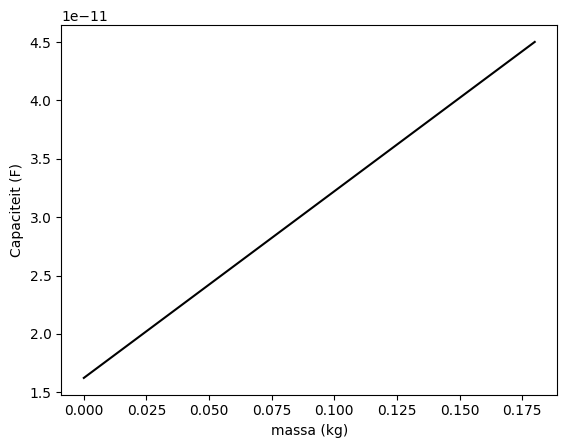

In [ ]:
d = 0.001
w=0.1
epsilon_r=2.5
m = np.array([0,180])*1e-3 #de veer kaan een maximaal verschil in massa van 180g meten

x = np.array([2.2,6.1])*1e-2 #onze platen kunnen tussen 2.2cm en 6.1 cm  op elkaar komen
A= x*w
C = capaciteit_plaatcondensator(A,d,epsilon_r)

plt.figure()
plt.plot(m,C, "k-")
plt.xlabel("massa (kg)")
plt.ylabel("Capaciteit (F)")
plt.show()

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

![foto sensor](opstelling2_arduino.jpeg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

We merken dat het lineaire verbant bij de kalibratie en verwachting hetzelfde is. Echter is er een sprong in capacoteit (van ongeveer 5e-10 F) in de gemeten capaciteit door de meerdere onzekerheden beschreven in de iteratie.

Onze sensor zou na veranderingen aangetoond in de iteratie geschikt zijn om het fenomeen dat we wilde meten daadwerkelijk te meten, door het elimineren van grote meetonzekerheden die onze resultaat beïnvloeden (zoals bv de afstand tussen de platen die grote veranderingen in de capaciteit kunnen veroorzaken).

We verwachten dat het een verbetering had opgeleverd (als we de tijd ervoor hadden gehad), echter is onze basis opstelling al best nauwkeurig aangezien we een lineair verbant kunnen aantonen, zoals verwacht.

Er is een verschil die uitgelegd kan worden door variaties in de afstand tussen de platen bij het verplaatsen van de plaat (voor elk gewicht) en het niet gebruik maken van een ideale veer, waarbij de grafiek laat zien dat de meetresultaten en de verwachte lijn dezelfde lineaire vorm hebben maar een constante verschuiving in de y-richting vertonen door een onjuist ingesteld nulpunt.

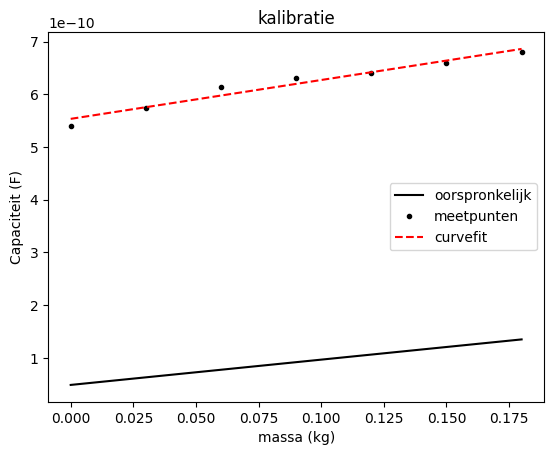

In [14]:
from scipy.optimize import curve_fit 
import numpy as np
import matplotlib.pyplot as plt

# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
d = 0.001
w=0.1
epsilon_r=2.5
m = np.array([0,180])*1e-3 #de veer kaan een maximaal verschil in massa van 180g meten

x = np.array([2.2,6.1])*1e-2 #onze platen kunnen tussen 2.2cm en 6.1 cm  op elkaar komen
A= x*w
C = capaciteit_plaatcondensator(A,d,epsilon_r)

g=9.81 #zwaartekracht constante
d=0.001 #[m] afstand tussen platen
w=0.1 #[m] breedte van platen
epsilon_r=2.5 #carton
epsilon_0 = 8.854187817e-12

#k=0.250*g/0.0517

C_gemeten =  np.array([540,574,613,631,640,660,680])*1e-12
#A = C_gemeten*d/(epsilon_r*epsilon_0) #Oppervlakte
# x = A/w
#x = np.array([0, 3.9/180*30, 3.9/180*60,3.9/180*90,3.9/180*120, 3.9/180*150, 3.9/180*180 ]) + 2.2
#m_uitgerekend = k*x / g
m2= np.array([0,30,60,90,120,150,180])*1e-3

# uit het omschrijven van formules blijkt dat C recht evenreding is met m dus dat er een lineaire fit gemaakt kan worden 
def f(x, a, b):
    return a*x + b

popt,pcov = curve_fit(f, m2, C_gemeten)


x_fit = np.linspace(min(m2), max(m2), 1000)
y_fit = f(x_fit, *popt)
plt.figure()
plt.title('kalibratie')
plt.plot(m,C, "k-", label='oorspronkelijk')
plt.plot(m2, C_gemeten, "k.", label='meetpunten')
plt.plot(x_fit, y_fit, "r--", label='curvefit')
plt.xlabel("massa (kg)")
plt.ylabel("Capaciteit (F)")
plt.legend()
plt.show()